/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:19:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:19:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:19:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:19:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:19:13] WARNING: /workspace/src/learner

[np.float64(0.1), np.float64(0.13333333333333333), np.float64(0.1), np.float64(0.03333333333333333), np.float64(0.5), np.float64(7.033333333333333), np.float64(14.966666666666667), np.float64(38.46666666666667), np.float64(77.36666666666666), np.float64(113.3), np.float64(47.96666666666667), np.float64(6.966666666666667), np.float64(1.5333333333333334), np.float64(0.5666666666666667), np.float64(0.8), np.float64(1.9333333333333333), np.float64(12.2), np.float64(127.66666666666667), np.float64(344.43333333333334), np.float64(377.3333333333333), np.float64(349.6), np.float64(180.26666666666668), np.float64(72.56666666666666), np.float64(15.0), np.float64(4.7), np.float64(3.966666666666667), np.float64(4.2), np.float64(5.666666666666667), np.float64(4.066666666666666), np.float64(14.9), np.float64(46.13333333333333), np.float64(68.36666666666666), np.float64(131.73333333333332), np.float64(137.23333333333332), np.float64(77.13333333333334)]
Random Forest Feature Importances:
             

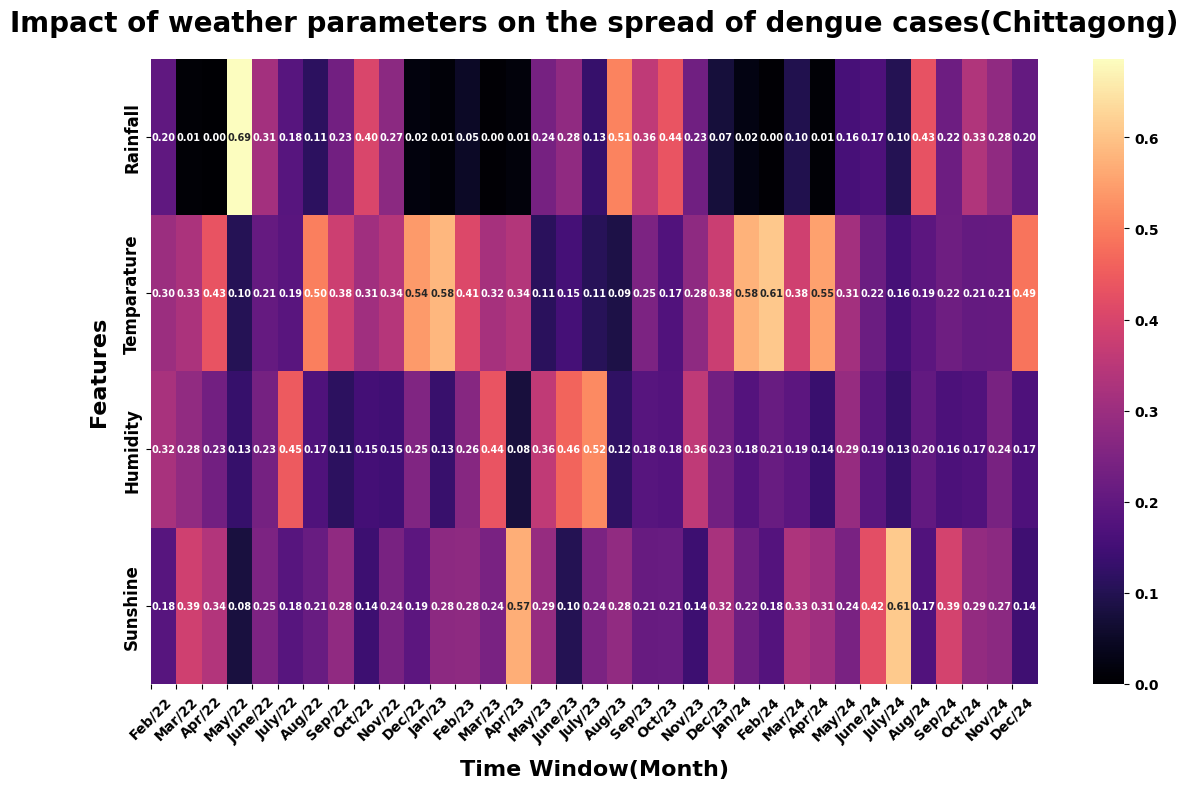

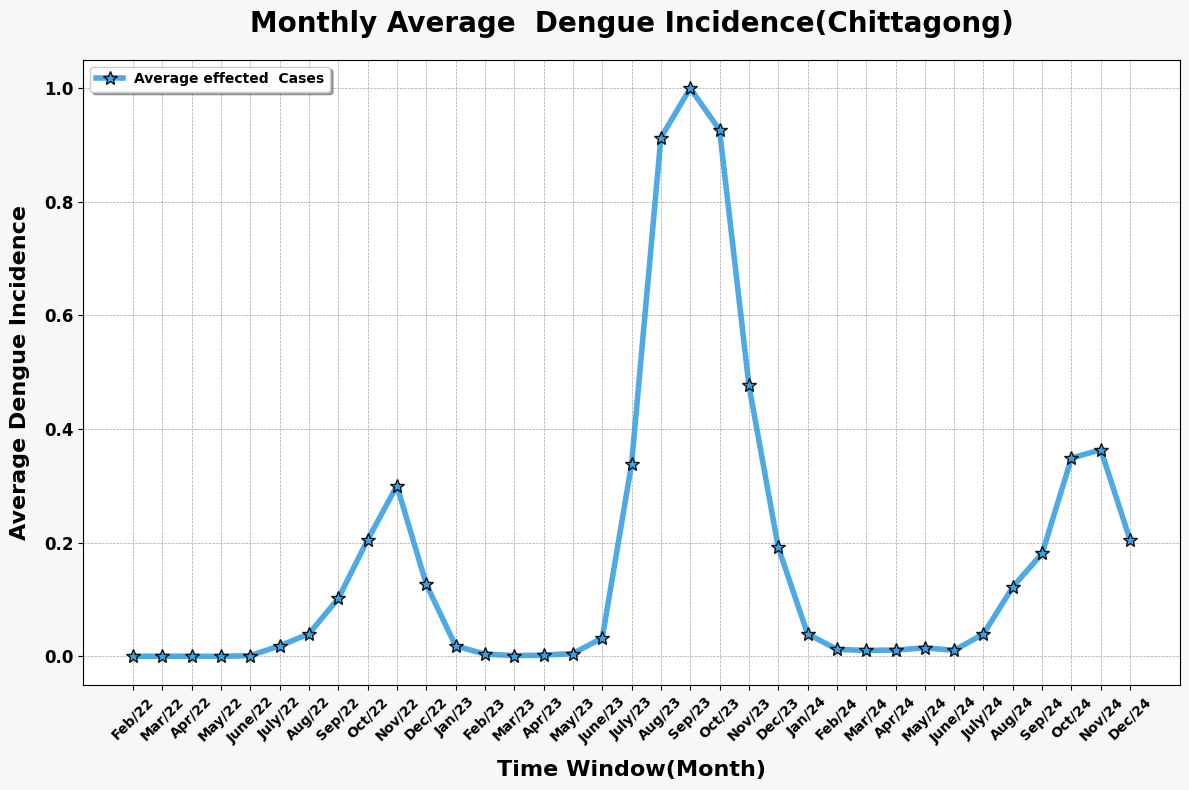

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/Chittagong.csv')
dfx
dfx1=dfx[['effected-chittagong','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected-chittagong'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())
    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200,max_features='log2', random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))


#print(avg)
print("Random Forest Feature Importances:")
print(rf_df)
print("\nXGBoost Feature Importances:")
print(xgb_df)

# Print the sum of feature importances for each month
print("\nSum of Random Forest Feature Importances per month:")
print(rf_df.sum())
print("\nSum of XGBoost Feature Importances per month:")
print(xgb_df.sum())

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of weather parameters on the spread of dengue cases(Chittagong)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#3BA1E3',markeredgecolor='black', markersize=10, marker='*', linewidth=4, linestyle='-',alpha=0.9, color='#3BA1E3', label="Average effected  Cases")


#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Chittagong)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

#plt.xticks(range(len(ind)), month)
#plt.grid(True)
#plt.legend(loc = 'upper right', ncol=5)
plt.show()

#plt.plot(range(len(ind)), avg2, markerfacecolor='yellow', markersize=6, marker='o', linewidth=2, linestyle='-', color='green', label="Rainfall")



[np.float64(0.3333333333333333), np.float64(0.36666666666666664), np.float64(0.6333333333333333), np.float64(4.9), np.float64(22.833333333333332), np.float64(40.46666666666667), np.float64(81.8), np.float64(235.1), np.float64(458.4), np.float64(444.3333333333333), np.float64(139.2), np.float64(15.533333333333333), np.float64(3.8333333333333335), np.float64(2.3), np.float64(2.6), np.float64(19.1), np.float64(148.86666666666667), np.float64(621.8666666666667), np.float64(1367.8), np.float64(1325.6666666666667), np.float64(1153.6666666666667), np.float64(720.1666666666666), np.float64(250.63333333333333), np.float64(31.333333333333332), np.float64(7.5), np.float64(4.4), np.float64(5.533333333333333), np.float64(11.1), np.float64(10.266666666666667), np.float64(29.433333333333334), np.float64(77.33333333333333), np.float64(197.03333333333333), np.float64(524.7), np.float64(608.6333333333333), np.float64(409.1333333333333)]
Random Forest Feature Importances:
               Feb/22    Mar/22 

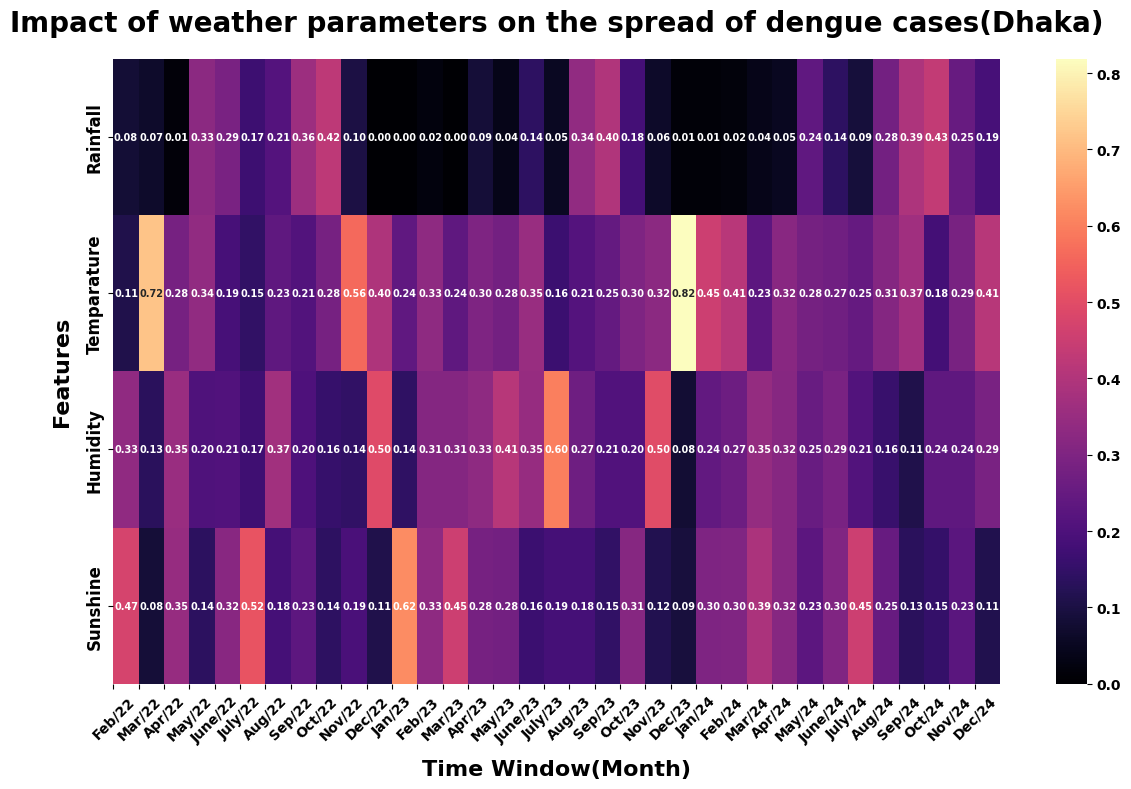

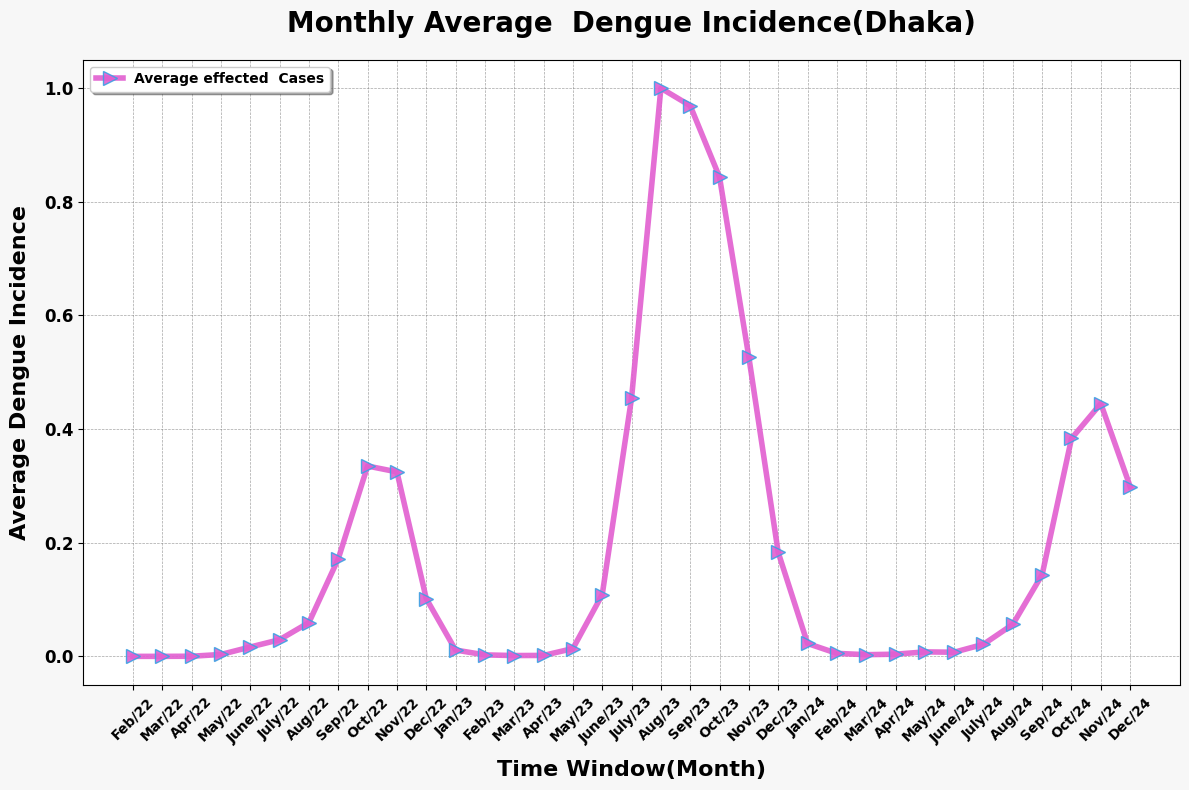

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/Dhaka.csv')
dfx
dfx1=dfx[['effected','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3= dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())

    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=220, random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200, random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))


#print(avg)
print("Random Forest Feature Importances:")
print(rf_df)
print("\nXGBoost Feature Importances:")
print(xgb_df)

# Print the sum of feature importances for each month
print("\nSum of Random Forest Feature Importances per month:")
print(rf_df.sum())
print("\nSum of XGBoost Feature Importances per month:")
print(xgb_df.sum())

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of weather parameters on the spread of dengue cases(Dhaka)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#E15ED0',markeredgecolor='#3BA1E3', markersize=10, marker='>', linewidth=4, linestyle='-',alpha=0.9, color='#E15ED0',label="Average effected  Cases")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Dhaka)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [0

[np.float64(0.03333333333333333), np.float64(0.1), np.float64(0.03333333333333333), np.float64(0.03333333333333333), np.float64(0.26666666666666666), np.float64(0.4666666666666667), np.float64(1.1333333333333333), np.float64(15.966666666666667), np.float64(40.1), np.float64(42.53333333333333), np.float64(10.6), np.float64(1.0333333333333334), np.float64(0.2), np.float64(0.26666666666666666), np.float64(0.13333333333333333), np.float64(0.2), np.float64(1.9666666666666666), np.float64(35.166666666666664), np.float64(129.86666666666667), np.float64(234.13333333333333), np.float64(342.53333333333336), np.float64(307.5), np.float64(101.3), np.float64(5.733333333333333), np.float64(0.6), np.float64(0.23333333333333334), np.float64(0.26666666666666666), np.float64(0.5666666666666667), np.float64(1.5), np.float64(3.3), np.float64(7.166666666666667), np.float64(29.733333333333334), np.float64(79.4), np.float64(116.16666666666667), np.float64(84.26666666666667)]


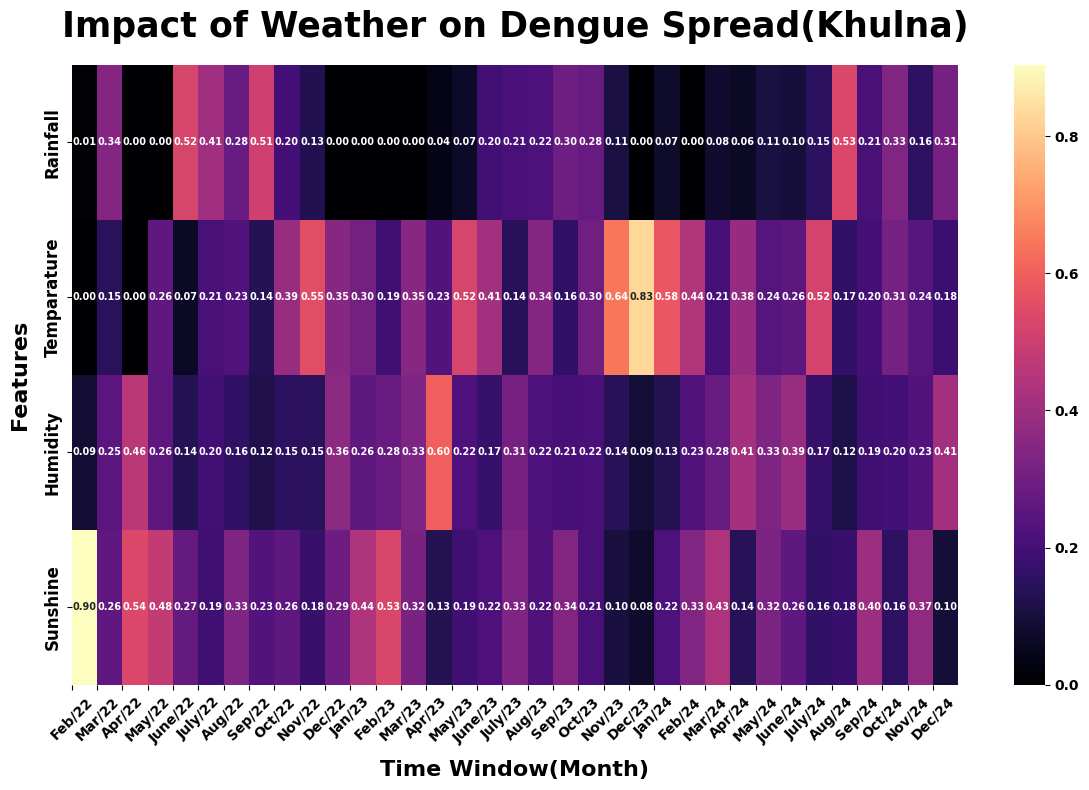

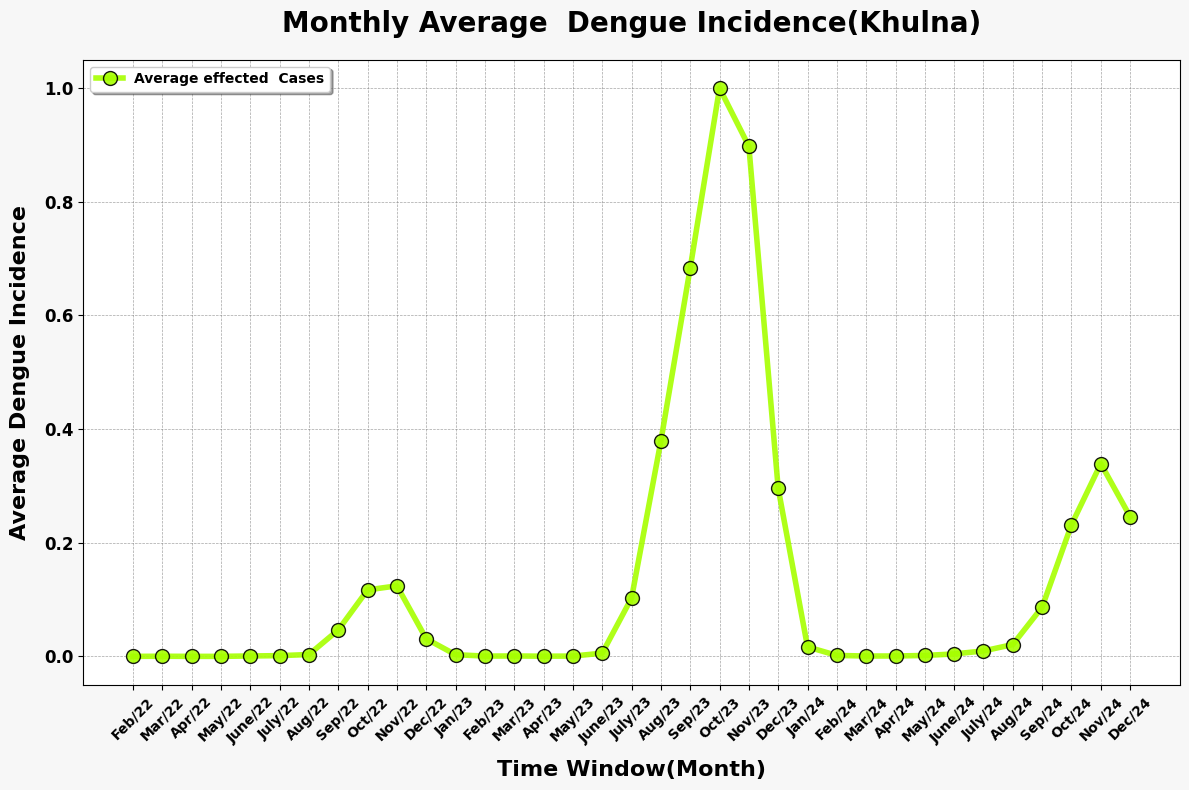

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/khulna.csv')
dfx
dfx1=dfx[['effected-khulna','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected-khulna'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())
    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200,max_features='log2', random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of Weather on Dengue Spread(Khulna)', fontsize=25,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#a6ff00',markeredgecolor='black', markersize=10, marker='o', linewidth=4, linestyle='-',alpha=0.9, color='#a6ff00',label="Average effected  Cases")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Khulna)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

Random Forest Feature Importances
               Feb/22    Mar/22    Apr/22    May/22   June/22   July/22  \
Rainfall     0.072458  0.055776  0.010091  0.377307  0.293643  0.167362   
Temparature  0.109829  0.757712  0.282865  0.323251  0.171740  0.130701   
Humidity     0.317363  0.122666  0.390563  0.192660  0.184168  0.172029   
Sunshine     0.500350  0.063846  0.316482  0.106783  0.350449  0.529909   

               Aug/22    Sep/22    Oct/22    Nov/22  ...    Mar/24    Apr/24  \
Rainfall     0.206652  0.378426  0.462596  0.087401  ...  0.041026  0.040863   
Temparature  0.234082  0.199733  0.290251  0.581407  ...  0.190749  0.335883   
Humidity     0.373126  0.183985  0.137734  0.139276  ...  0.350921  0.303157   
Sunshine     0.186140  0.237857  0.109419  0.191916  ...  0.417304  0.320097   

               May/24   June/24   July/24    Aug/24    Sep/24    Oct/24  \
Rainfall     0.252670  0.160707  0.075638  0.270621  0.415145  0.505072   
Temparature  0.246140  0.228872  0.2514

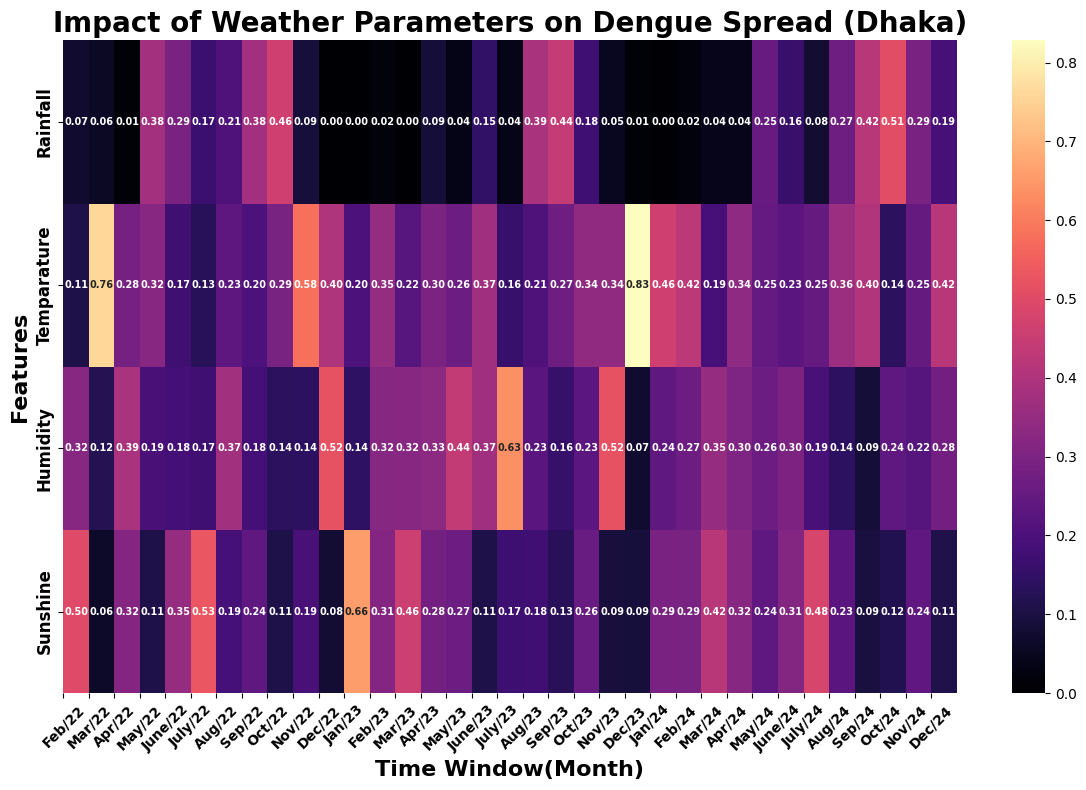

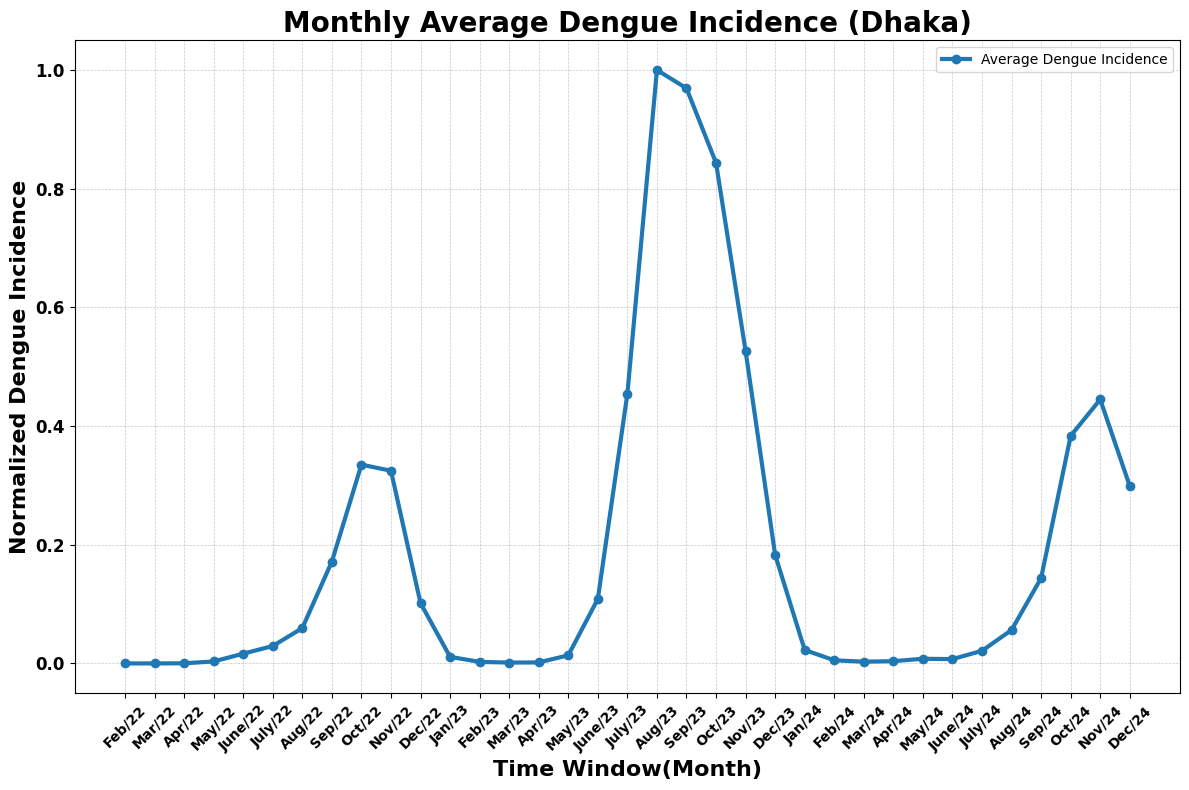

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# Load Dataset
# =========================

dfx = pd.read_csv('/content/Dhaka.csv')

dfx1 = dfx[['effected', 'Rainfall', 'Temparature',
            'Humidity', 'Sunshine']]

# =========================
# Time Windows
# =========================

month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22',
         'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22',
         'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23',
         'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23',
         'Oct/23', 'Nov/23', 'Dec/23', 'Jan/24', 'Feb/24',
         'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24',
         'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']

# =========================
# Containers
# =========================

rf_importance_dict = {}
xgb_importance_dict = {}

avg_effected = []
avg_rainfall = []
avg_temp = []
avg_humidity = []
avg_sunshine = []

rf_scores = []
xgb_scores = []

# =========================
# Scaling
# =========================

scaler = StandardScaler()

# =========================
# Window Size
# =========================

dur = len(dfx1) // 36
indx = 0

# =========================
# Repeated CV
# =========================

rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

# =========================
# Parameter Grids
# =========================

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

# =========================
# Main Loop
# =========================

for i in range(0, 35):

    # Current Window
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx += dur

    # Next Window
    dfx3 = dfx1.iloc[indx:indx+dur].copy()

    # Average Values
    avg_effected.append(dfx3['effected'].mean())
    # Features and Target
    X = dfx2.iloc[:, 1:]
    y = dfx3.iloc[:, 0]

    # Standardization
    X_scaled = scaler.fit_transform(X)

    # =====================================
    # Random Forest with GridSearchCV
    # =====================================

    rf_model = RandomForestRegressor(random_state=42)

    rf_grid = GridSearchCV(
        estimator=rf_model,
        param_grid=rf_param_grid,
        cv=rkf,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    rf_grid.fit(X_scaled, y)

    best_rf = rf_grid.best_estimator_

    # Feature Importance
    rf_importance_dict[month[i]] = best_rf.feature_importances_

    # Prediction
    rf_pred = best_rf.predict(X_scaled)

    # Metrics
    rf_rmse = np.sqrt(mean_squared_error(y, rf_pred))
    rf_r2 = r2_score(y, rf_pred)

    rf_scores.append([rf_rmse, rf_r2])

    # =====================================
    # XGBoost with GridSearchCV
    # =====================================


# =========================
# DataFrames
# =========================

rf_df = pd.DataFrame(
    rf_importance_dict,
    index=X.columns
)


# =========================
# Normalize Averages
# =========================

minmax = MinMaxScaler()

avg_effected = minmax.fit_transform(
    np.array(avg_effected).reshape(-1, 1)
)


# =========================
# Print Results
# =========================

print("Random Forest Feature Importances")
print(rf_df)

# =========================
# Average Scores
# =========================

rf_scores = np.array(rf_scores)

print("\nRandom Forest Average RMSE:",
      rf_scores[:, 0].mean())

print("Random Forest Average R2:",
      rf_scores[:, 1].mean())


# =========================
# Heatmap
# =========================

plt.figure(figsize=(12, 8))

sns.heatmap(
    rf_df,
    annot=True,
    cmap="magma",
    fmt=".2f",
    annot_kws={"size": 7, 'fontweight': 'bold'}
)

plt.xlabel(
    'Time Window(Month)',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    'Features',
    fontsize=16,
    fontweight='bold'
)

plt.title(
    'Impact of Weather Parameters on Dengue Spread (Dhaka)',
    fontsize=20,
    fontweight='bold'
)

plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# =========================
# Dengue Incidence Plot
# =========================

plt.figure(figsize=(12, 8))

plt.plot(
    range(len(avg_effected)),
    avg_effected,
    marker='o',
    linewidth=3,
    label='Average Dengue Incidence'
)

plt.xlabel(
    'Time Window(Month)',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    'Normalized Dengue Incidence',
    fontsize=16,
    fontweight='bold'
)

plt.title(
    'Monthly Average Dengue Incidence (Dhaka)',
    fontsize=20,
    fontweight='bold'
)

plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    linestyle='--',
    linewidth=0.5,
    alpha=0.7
)

plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:13:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:13:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:13:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:13:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [0

[np.float64(0.3333333333333333), np.float64(0.36666666666666664), np.float64(0.6333333333333333), np.float64(4.9), np.float64(22.833333333333332), np.float64(40.46666666666667), np.float64(81.8), np.float64(235.1), np.float64(458.4), np.float64(444.3333333333333), np.float64(139.2), np.float64(15.533333333333333), np.float64(3.8333333333333335), np.float64(2.3), np.float64(2.6), np.float64(19.1), np.float64(148.86666666666667), np.float64(621.8666666666667), np.float64(1367.8), np.float64(1325.6666666666667), np.float64(1153.6666666666667), np.float64(720.1666666666666), np.float64(250.63333333333333), np.float64(31.333333333333332), np.float64(7.5), np.float64(4.4), np.float64(5.533333333333333), np.float64(11.1), np.float64(10.266666666666667), np.float64(29.433333333333334), np.float64(77.33333333333333), np.float64(197.03333333333333), np.float64(524.7), np.float64(608.6333333333333), np.float64(409.1333333333333)]


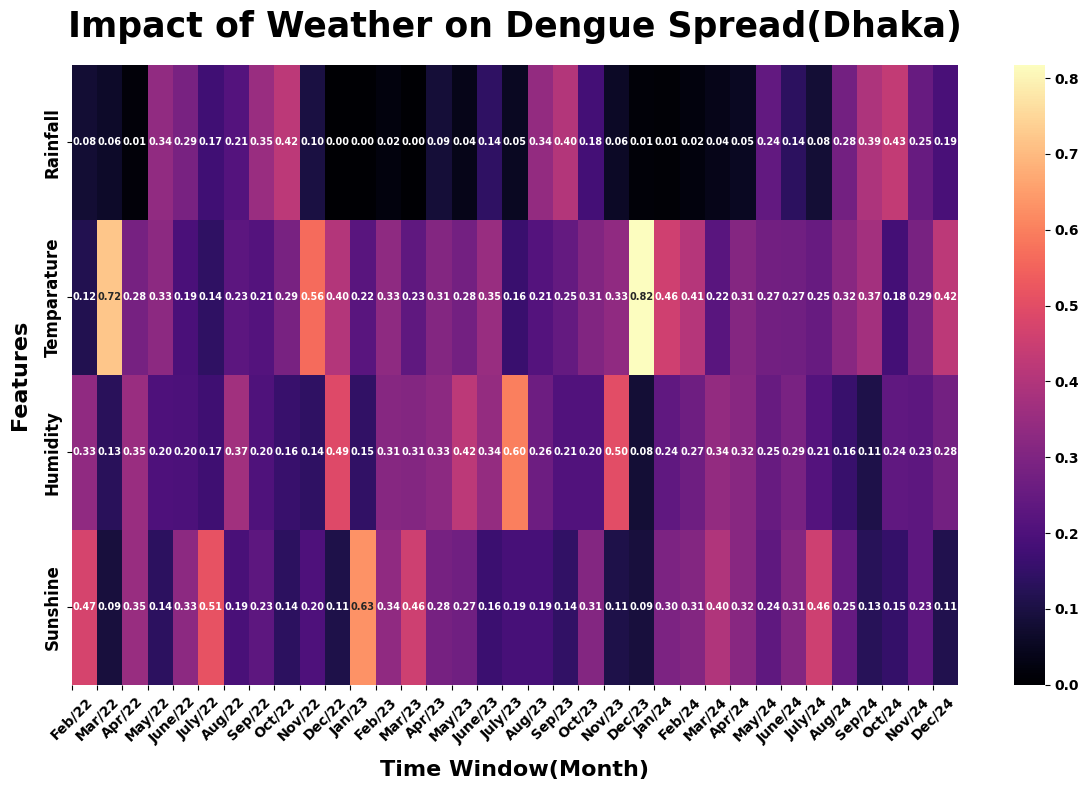

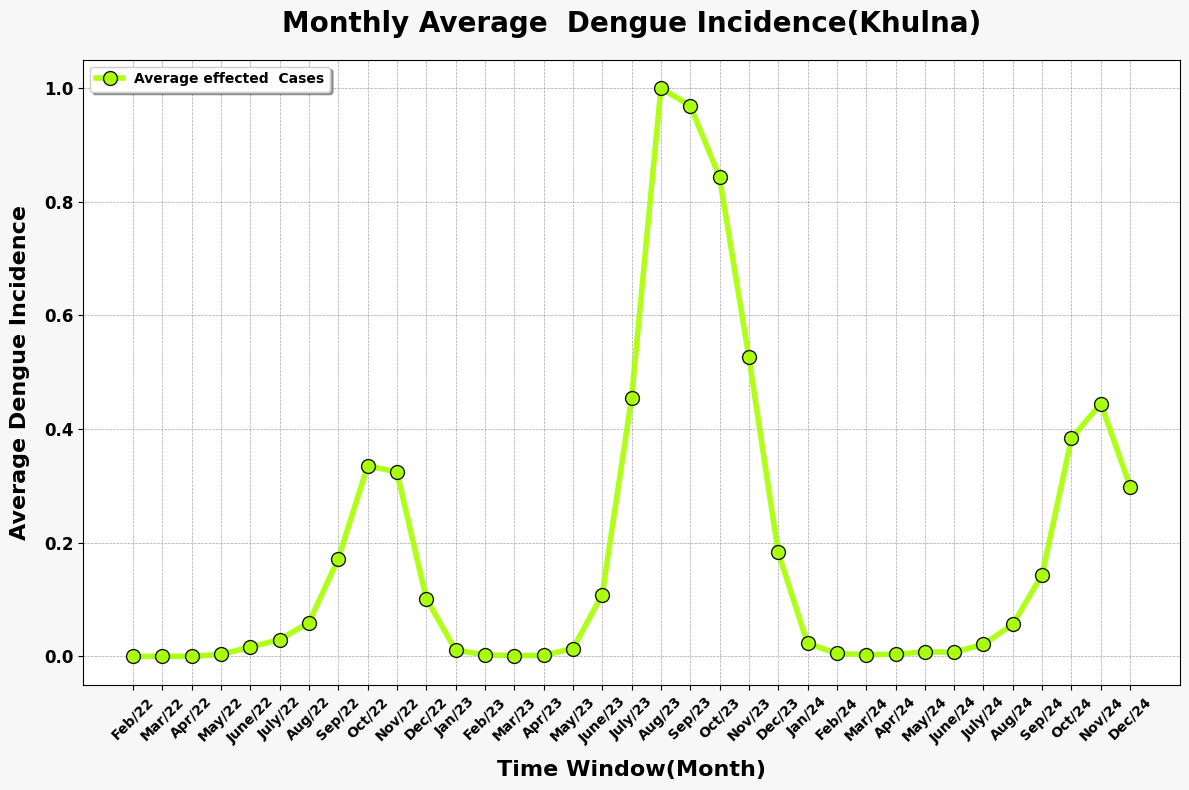

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/Dhaka.csv')
dfx
dfx1=dfx[['effected','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())
    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200,max_features='log2', random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of Weather on Dengue Spread(Dhaka)', fontsize=25,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#a6ff00',markeredgecolor='black', markersize=10, marker='o', linewidth=4, linestyle='-',alpha=0.9, color='#a6ff00',label="Average effected  Cases")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Khulna)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:04:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:04:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:04:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:04:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [0

[np.float64(0.03333333333333333), np.float64(0.1), np.float64(0.03333333333333333), np.float64(0.03333333333333333), np.float64(0.26666666666666666), np.float64(0.4666666666666667), np.float64(1.1333333333333333), np.float64(15.966666666666667), np.float64(40.1), np.float64(42.53333333333333), np.float64(10.6), np.float64(1.0333333333333334), np.float64(0.2), np.float64(0.26666666666666666), np.float64(0.13333333333333333), np.float64(0.2), np.float64(1.9666666666666666), np.float64(35.166666666666664), np.float64(129.86666666666667), np.float64(234.13333333333333), np.float64(342.53333333333336), np.float64(307.5), np.float64(101.3), np.float64(5.733333333333333), np.float64(0.6), np.float64(0.23333333333333334), np.float64(0.26666666666666666), np.float64(0.5666666666666667), np.float64(1.5), np.float64(3.3), np.float64(7.166666666666667), np.float64(29.733333333333334), np.float64(79.4), np.float64(116.16666666666667), np.float64(84.26666666666667)]


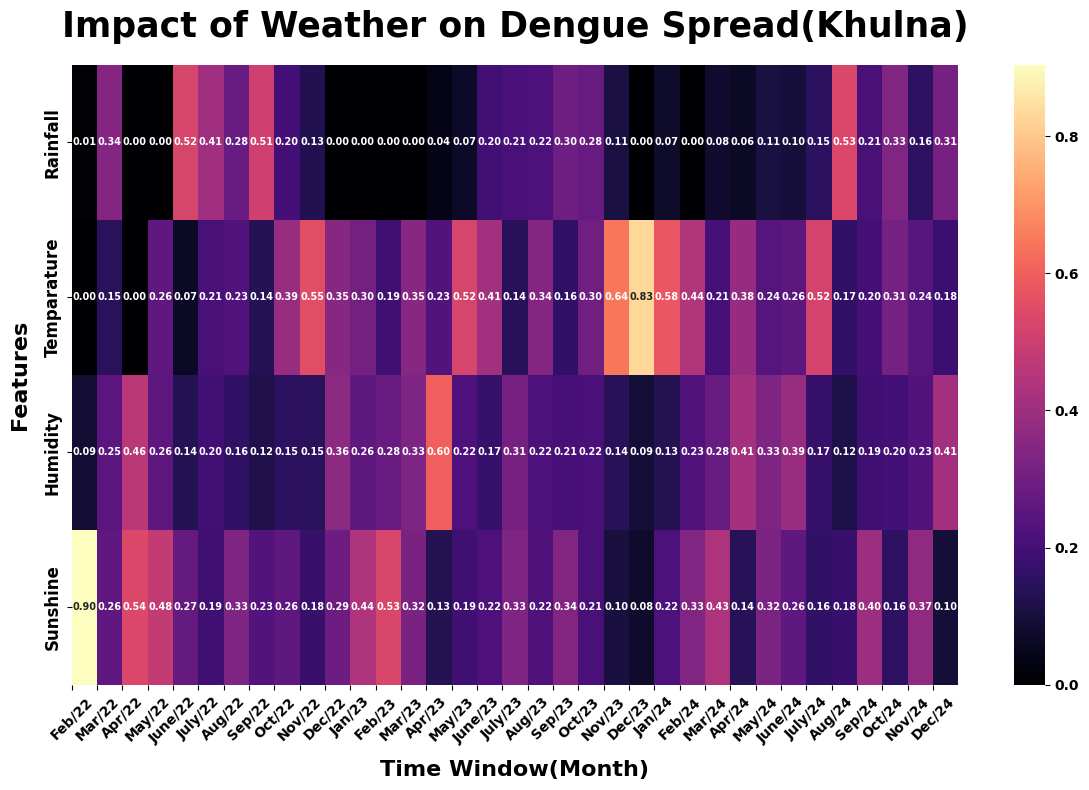

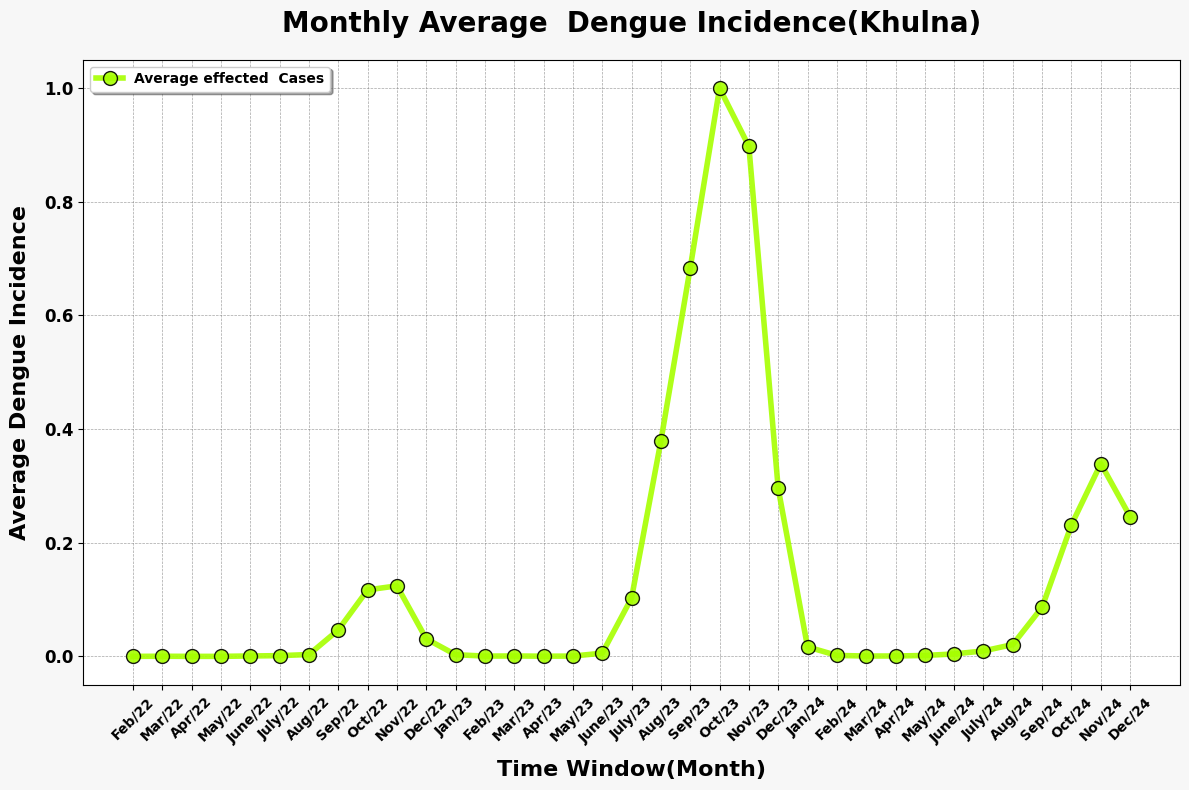

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/khulna.csv')
dfx
dfx1=dfx[['effected-khulna','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected-khulna'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())
    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200,max_features='log2', random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of Weather on Dengue Spread(Khulna)', fontsize=25,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#a6ff00',markeredgecolor='black', markersize=10, marker='o', linewidth=4, linestyle='-',alpha=0.9, color='#a6ff00',label="Average effected  Cases")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Khulna)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:09:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [0

[np.float64(0.1), np.float64(0.13333333333333333), np.float64(0.1), np.float64(0.03333333333333333), np.float64(0.5), np.float64(7.033333333333333), np.float64(14.966666666666667), np.float64(38.46666666666667), np.float64(77.36666666666666), np.float64(113.3), np.float64(47.96666666666667), np.float64(6.966666666666667), np.float64(1.5333333333333334), np.float64(0.5666666666666667), np.float64(0.8), np.float64(1.9333333333333333), np.float64(12.2), np.float64(127.66666666666667), np.float64(344.43333333333334), np.float64(377.3333333333333), np.float64(349.6), np.float64(180.26666666666668), np.float64(72.56666666666666), np.float64(15.0), np.float64(4.7), np.float64(3.966666666666667), np.float64(4.2), np.float64(5.666666666666667), np.float64(4.066666666666666), np.float64(14.9), np.float64(46.13333333333333), np.float64(68.36666666666666), np.float64(131.73333333333332), np.float64(137.23333333333332), np.float64(77.13333333333334)]


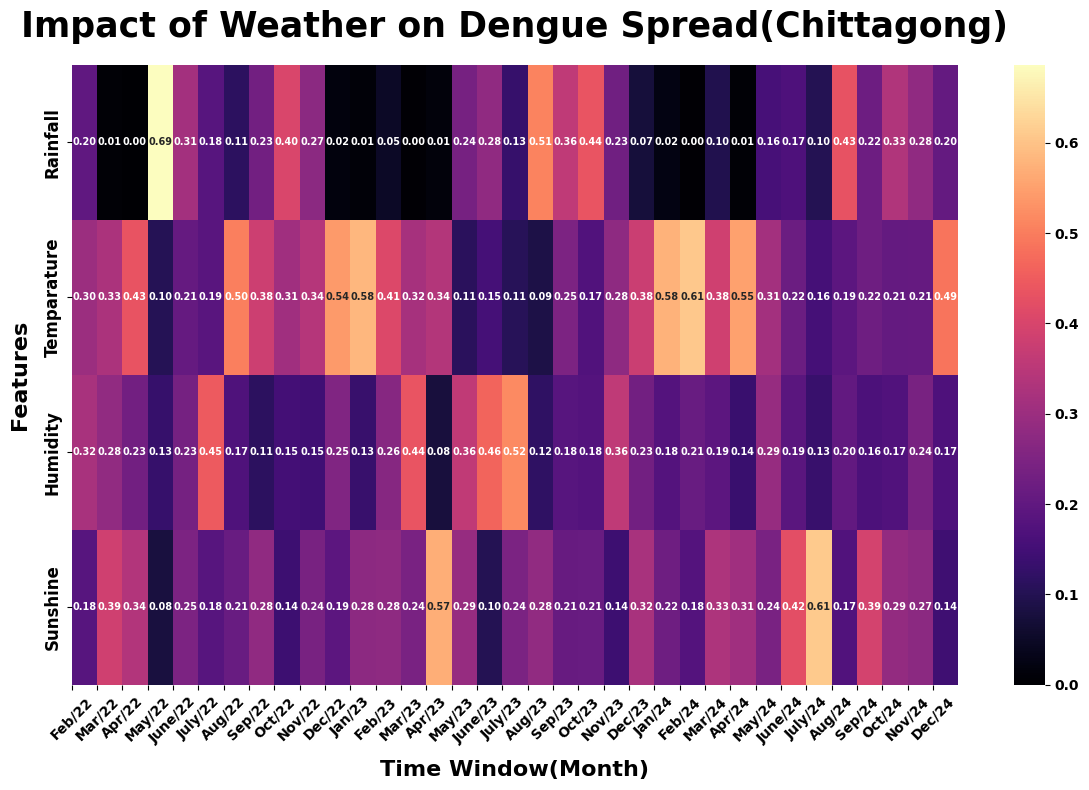

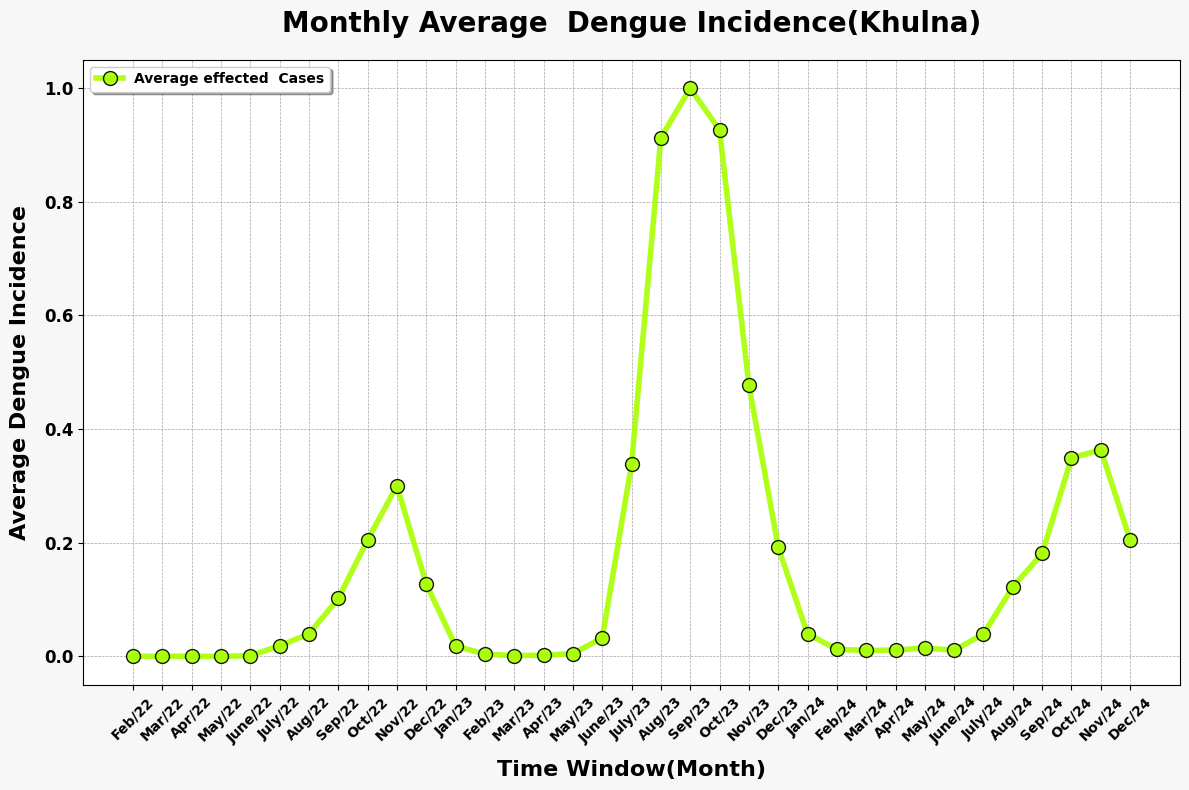

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/Chittagong.csv')
dfx
dfx1=dfx[['effected-chittagong','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected-chittagong'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())
    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200,max_features='log2', random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of Weather on Dengue Spread(Chittagong)', fontsize=25,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#a6ff00',markeredgecolor='black', markersize=10, marker='o', linewidth=4, linestyle='-',alpha=0.9, color='#a6ff00',label="Average effected  Cases")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Khulna)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

[np.float64(0.0), np.float64(0.03333333333333333), np.float64(0.0), np.float64(0.0), np.float64(0.26666666666666666), np.float64(0.5333333333333333), np.float64(0.7666666666666667), np.float64(3.6333333333333333), np.float64(10.9), np.float64(14.1), np.float64(3.6333333333333333), np.float64(0.3), np.float64(0.1), np.float64(0.06666666666666667), np.float64(0.03333333333333333), np.float64(0.36666666666666664), np.float64(2.1), np.float64(21.866666666666667), np.float64(77.26666666666667), np.float64(72.13333333333334), np.float64(49.96666666666667), np.float64(34.9), np.float64(14.9), np.float64(2.2), np.float64(0.2), np.float64(0.26666666666666666), np.float64(0.4), np.float64(0.5666666666666667), np.float64(0.4666666666666667), np.float64(0.8), np.float64(2.433333333333333), np.float64(7.5), np.float64(27.3), np.float64(35.13333333333333), np.float64(24.333333333333332)]


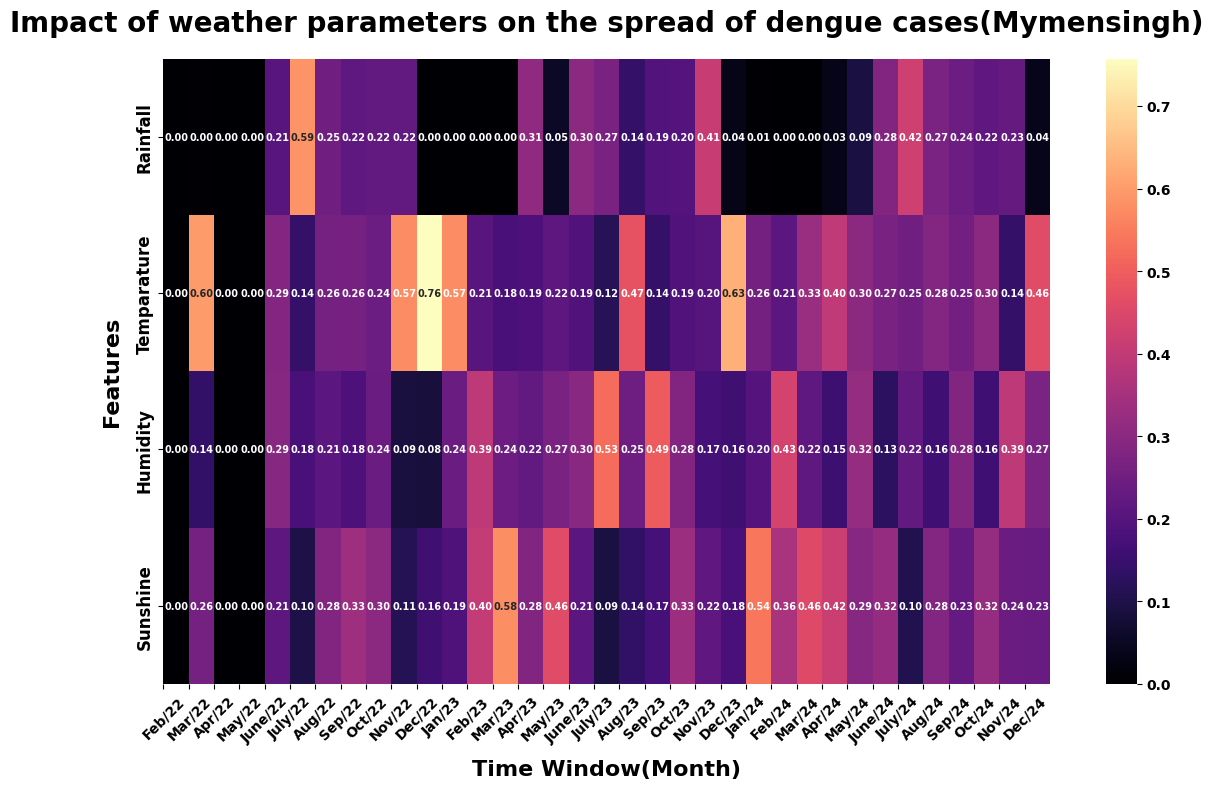

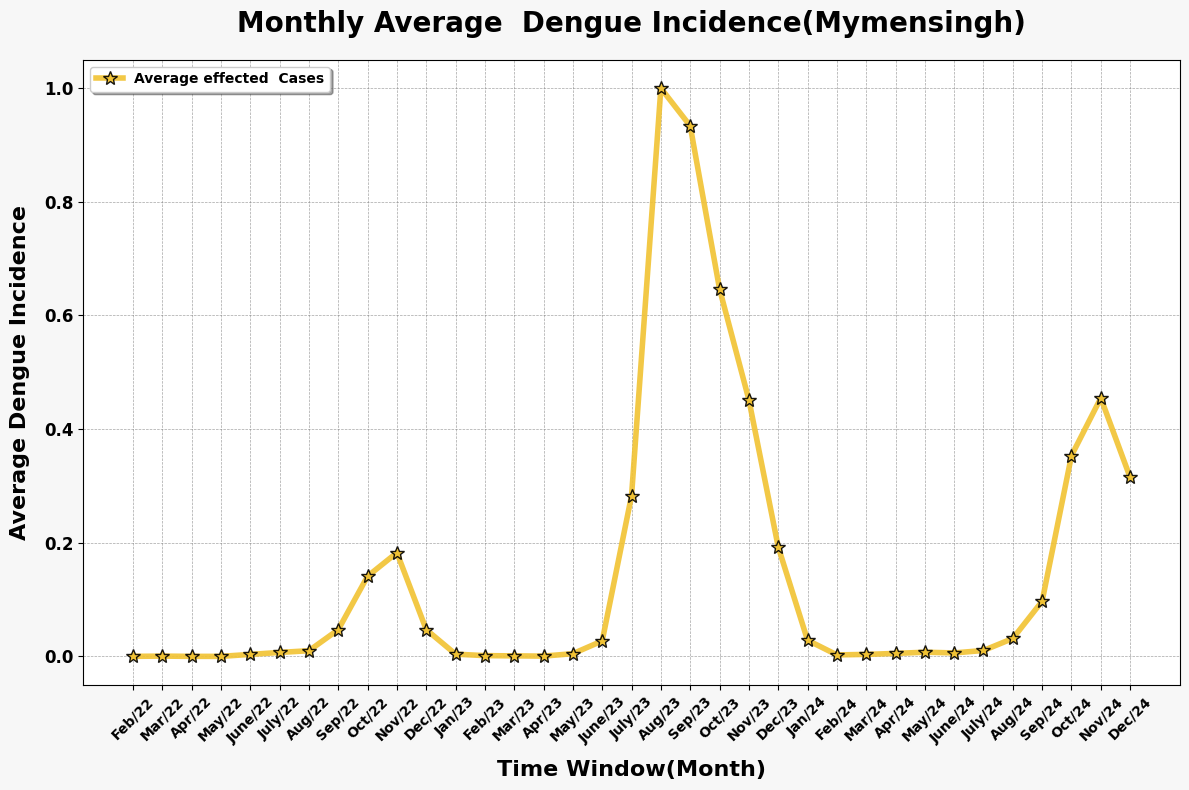

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/Mymensingh.csv')
dfx
dfx1=dfx[['effected-Mymensingh','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected-Mymensingh'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())
    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200, random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))


plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of weather parameters on the spread of dengue cases(Mymensingh)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#f1c232',markeredgecolor='black', markersize=10, marker='*', linewidth=4, linestyle='-',alpha=0.9, color='#f1c232',label="Average effected  Cases")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Mymensingh)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

    Rainfall  Temparature   Humidity  Sunshine
0   0.000000    17.983333  79.666667      7.04
1   0.000000    16.283333  87.833333      3.42
2   0.000000    17.200000  81.333333      7.16
3   0.000000    16.133333  82.666667      7.00
4   0.000000    16.216667  82.333333      6.76
5   0.000000    17.266667  81.500000      7.44
6   0.000000    18.716667  79.333333      8.12
7   0.000000    19.500000  78.000000      8.32
8   0.000000    19.916667  78.500000      8.60
9   0.000000    20.383333  80.000000      6.14
10  0.000000    21.133333  80.166667      4.66
11  4.500000    19.250000  86.500000      0.02
12  0.500000    19.450000  85.333333      4.50
13  0.000000    18.516667  82.666667      0.16
14  0.000000    18.066667  80.166667      3.26
15  0.166667    16.816667  73.833333      8.62
16  0.000000    17.083333  77.666667      8.44
17  0.000000    17.250000  79.000000      7.54
18  0.000000    16.816667  81.666667      7.72
19  0.000000    16.433333  80.000000      7.46
20  0.000000 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:17:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


     Rainfall  Temparature   Humidity  Sunshine
30   0.000000    17.966667  72.500000      8.22
31   0.000000    19.316667  77.666667      8.00
32   0.000000    20.133333  76.000000      7.68
33   0.000000    21.450000  83.500000      4.52
34   0.500000    17.533333  93.000000      0.72
35  32.833333    17.400000  76.666667      7.68
36   0.000000    16.566667  76.000000      9.20
37   0.000000    17.050000  78.000000      8.56
38   0.000000    18.366667  77.333333      8.54
39   0.000000    19.950000  80.166667      6.44
40   0.333333    18.916667  89.166667      0.72
41   0.500000    18.666667  83.666667      3.76
42   0.000000    17.666667  70.333333      9.20
43   0.000000    18.333333  69.333333      9.48
44   0.000000    18.616667  70.000000      9.60
45   0.000000    18.583333  69.500000      9.64
46   0.000000    18.466667  70.500000      9.32
47   0.000000    19.433333  73.333333      9.16
48   0.000000    19.733333  68.833333      9.42
49   0.000000    19.900000  65.833333   

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:17:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    Rainfall  Temparature   Humidity  Sunshine
60       0.0    23.433333  69.000000      8.80
61       0.0    23.383333  71.833333      9.32
62       0.0    23.850000  68.000000      9.20
63       0.0    24.666667  69.666667      8.80
64       0.0    24.233333  65.833333      9.42
65       0.0    24.400000  69.166667      9.30
66       0.0    24.750000  69.666667      9.32
67       0.0    24.466667  68.333333      9.58
68       0.0    24.583333  67.166667      9.38
69       0.0    24.816667  67.000000      9.46
70       0.0    25.283333  66.500000      9.18
71       0.0    25.116667  66.000000      9.38
72       0.0    25.666667  66.166667      9.72
73       0.0    26.666667  65.666667      9.44
74       0.0    27.700000  62.500000      9.20
75       0.0    27.750000  65.000000      9.32
76       0.0    27.566667  62.666667      9.62
77       0.0    27.683333  60.166667      9.60
78       0.0    27.766667  65.000000      9.14
79       0.0    27.866667  76.166667      8.04
80       0.0 

...

       Rainfall  Temparature   Humidity  Sunshine
990   37.833333    29.650000  83.000000      8.38
991    0.166667    30.300000  81.500000      8.72
992    0.000000    31.400000  81.833333      6.70
993    0.166667    31.866667  80.500000      8.70
994   10.000000    30.000000  82.333333      4.82
995    4.500000    31.183333  80.333333      9.40
996    0.000000    30.933333  85.166667      2.62
997    0.000000    29.300000  85.333333      3.98
998    9.500000    27.266667  93.333333      0.18
999   68.500000    26.516667  95.000000      0.00
1000  38.833333    28.500000  87.666667      5.46
1001   8.000000    29.933333  83.333333      8.10
1002   0.333333    30.550000  83.166667      5.96
1003   0.000000    31.183333  83.000000      4.76
1004   2.500000    30.133333  87.000000      2.20
1005   0.833333    29.416667  87.500000      0.06
1006   8.833333    27.783333  92.833333      0.00
1007  19.000000    27.516667  92.166667      0.14
1008  36.333333    27.666667  90.500000      0.52


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:17:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


       Rainfall  Temparature   Humidity  Sunshine
1020   0.000000    28.350000  85.166667      1.88
1021   5.000000    27.050000  89.833333      2.72
1022  28.166667    26.833333  88.666667      1.76
1023  22.333333    27.550000  83.833333      7.56
1024   0.000000    27.550000  83.166667      7.38
1025   0.000000    28.533333  81.166667      8.04
1026   0.000000    26.766667  88.833333      0.22
1027  15.166667    24.766667  93.500000      0.04
1028  39.166667    26.116667  92.166667      0.14
1029  31.666667    28.350000  84.166667      7.22
1030   2.500000    28.333333  83.500000      6.68
1031   0.000000    28.700000  81.833333      7.90
1032   0.000000    28.616667  82.666667      7.20
1033   0.000000    29.000000  82.333333      8.10
1034   0.000000    28.850000  84.666667      7.28
1035   1.833333    28.183333  82.666667      6.84
1036   0.000000    27.750000  83.000000      6.70
1037   0.000000    27.350000  84.500000      5.26
1038   0.000000    27.216667  82.000000      6.42


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:17:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[np.float64(0.03333333333333333), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.03333333333333333), np.float64(0.0), np.float64(0.03333333333333333), np.float64(0.5333333333333333), np.float64(1.3666666666666667), np.float64(3.2), np.float64(0.5333333333333333), np.float64(0.13333333333333333), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.4), np.float64(14.266666666666667), np.float64(57.8), np.float64(47.4), np.float64(36.56666666666667), np.float64(20.366666666666667), np.float64(7.466666666666667), np.float64(0.6666666666666666), np.float64(0.1), np.float64(0.0), np.float64(0.13333333333333333), np.float64(0.0), np.float64(0.13333333333333333), np.float64(0.06666666666666667), np.float64(0.7333333333333333), np.float64(2.033333333333333), np.float64(19.633333333333333), np.float64(19.233333333333334), np.float64(7.466666666666667)]
Random Forest Feature Importances:
               Feb/22  Mar/22  Apr/22  May/22   June/22  July/22

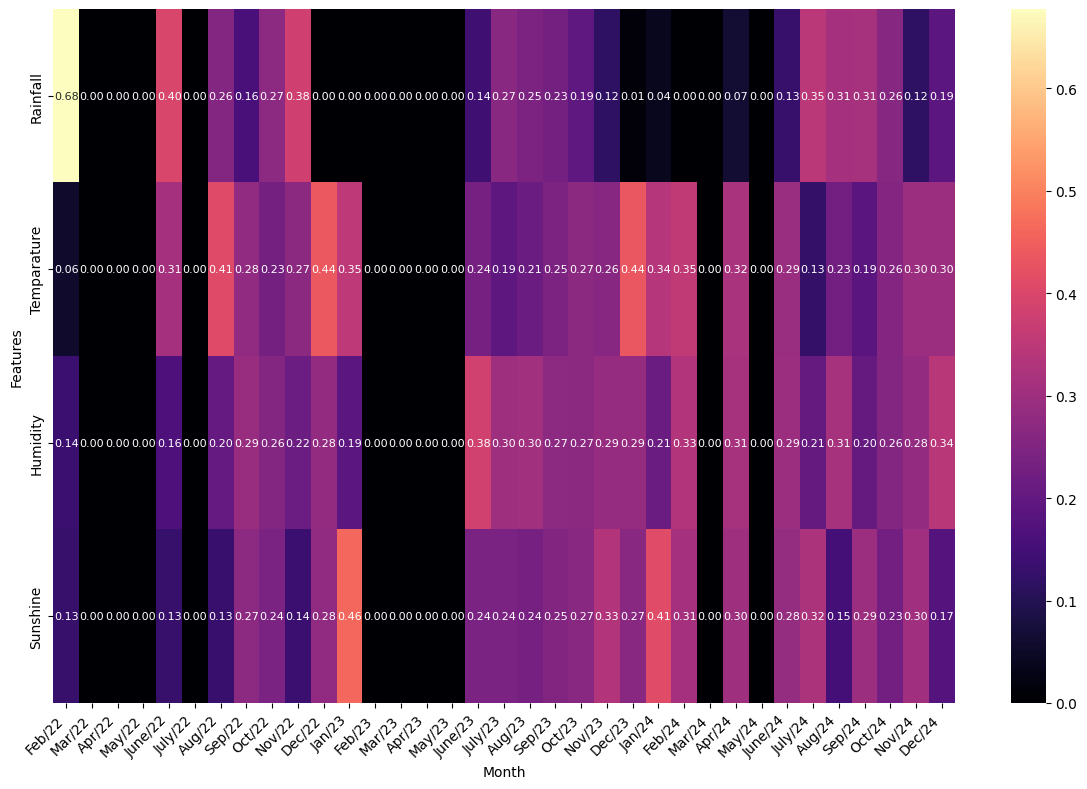

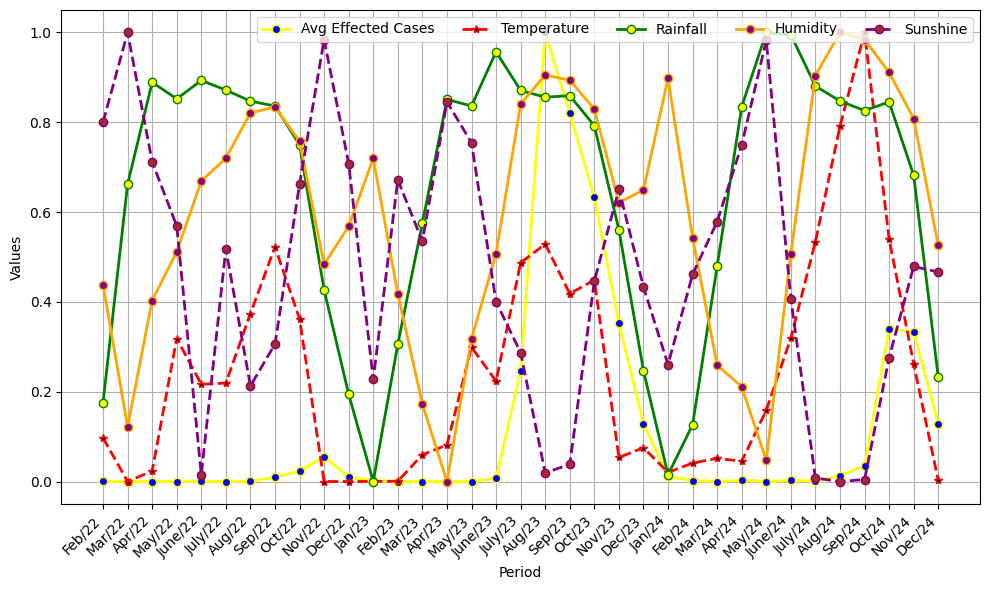

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfx=pd.read_csv('/content/Rangpur.csv')
dfx
dfx1=dfx[['effected-Rangpur','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

avg = []
avg1=[]
avg2=[]
avg3=[]
avg4=[]

indx=0
dur= len(dfx1)//36

#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['effected-Rangpur'].mean())
    avg1.append(dfx3['Rainfall'].mean())
    avg2.append(dfx3['Temparature'].mean())
    avg3.append(dfx3['Humidity'].mean())
    avg4.append(dfx3['Sunshine'].mean())
    #print(dfx3['effected'])

    #print(dfx2)
    rf_model=RandomForestRegressor(n_estimators=200,max_features='log2', random_state=42)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    print(x)
    print(y)
    x_scaled = scaler.fit_transform(x)
    rf_model.fit(x_scaled,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200,max_features='log2', random_state=42)
    xgb_model.fit(x_scaled,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)

print(avg)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
avg1 = scaler.fit_transform(np.array(avg1).reshape(-1, 1))
avg2 = scaler.fit_transform(np.array(avg2).reshape(-1, 1))
avg3 = scaler.fit_transform(np.array(avg3).reshape(-1, 1))
avgx = scaler.fit_transform(np.array(avg4).reshape(-1, 1))


#print(avg)
print("Random Forest Feature Importances:")
print(rf_df)
print("\nXGBoost Feature Importances:")
print(xgb_df)

# Print the sum of feature importances for each month
print("\nSum of Random Forest Feature Importances per month:")
print(rf_df.sum())
print("\nSum of XGBoost Feature Importances per month:")
print(xgb_df.sum())

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 8})
#plt.title("Monthly Feature Importance (Random Forest) - 2022 (Dhaka)")
plt.xlabel("Month")
plt.ylabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='blue', markersize=6, marker='o', linewidth=2, linestyle='-', color='yellow', label="Avg Effected Cases")
plt.plot(range(len(ind)), avg1, markerfacecolor='black', markersize=6, marker='*', linewidth=2, linestyle='--', color='red', label="Temperature")
plt.plot(range(len(ind)), avg2, markerfacecolor='yellow', markersize=6, marker='o', linewidth=2, linestyle='-', color='green', label="Rainfall")
plt.plot(range(len(ind)), avg3, markerfacecolor='purple', markersize=6, marker='o', linewidth=2, linestyle='-', color='orange', label="Humidity")
plt.plot(range(len(ind)), avgx, markerfacecolor='brown', markersize=6, marker='o', linewidth=2, linestyle='--', color='purple', label="Sunshine")

plt.xlabel('Period')
plt.ylabel('Values')
#plt.title('Average Cases')
plt.xticks(rotation=45, ha='right')
plt.xticks(range(len(ind)), month)
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right', ncols=5)
plt.show()

               Jan/22    Feb/22  Mar/22  Apr/22  May/22  June/22   July/22  \
Rainfall     0.017747  0.000000     0.0     0.0     0.0      0.0  0.426467   
Humidity     0.450623  0.364103     0.0     0.0     0.0      0.0  0.208002   
Temparature  0.272688  0.095509     0.0     0.0     0.0      0.0  0.162306   
Sunshine     0.258942  0.540388     0.0     0.0     0.0      0.0  0.203225   

               Aug/22    Sep/22    Oct/22  ...    Mar/24    Apr/24    May/24  \
Rainfall     0.233228  0.164392  0.269266  ...  0.079232  0.016668  0.110950   
Humidity     0.325257  0.187495  0.099165  ...  0.257012  0.276441  0.186190   
Temparature  0.152372  0.298305  0.387183  ...  0.370692  0.434602  0.408052   
Sunshine     0.289143  0.349808  0.244386  ...  0.293065  0.272289  0.294808   

              June/24   July/24    Aug/24    Sep/24    Oct/24    Nov/24  \
Rainfall     0.140787  0.284537  0.247661  0.294814  0.322330  0.024511   
Humidity     0.210151  0.174019  0.228676  0.179423  0.168

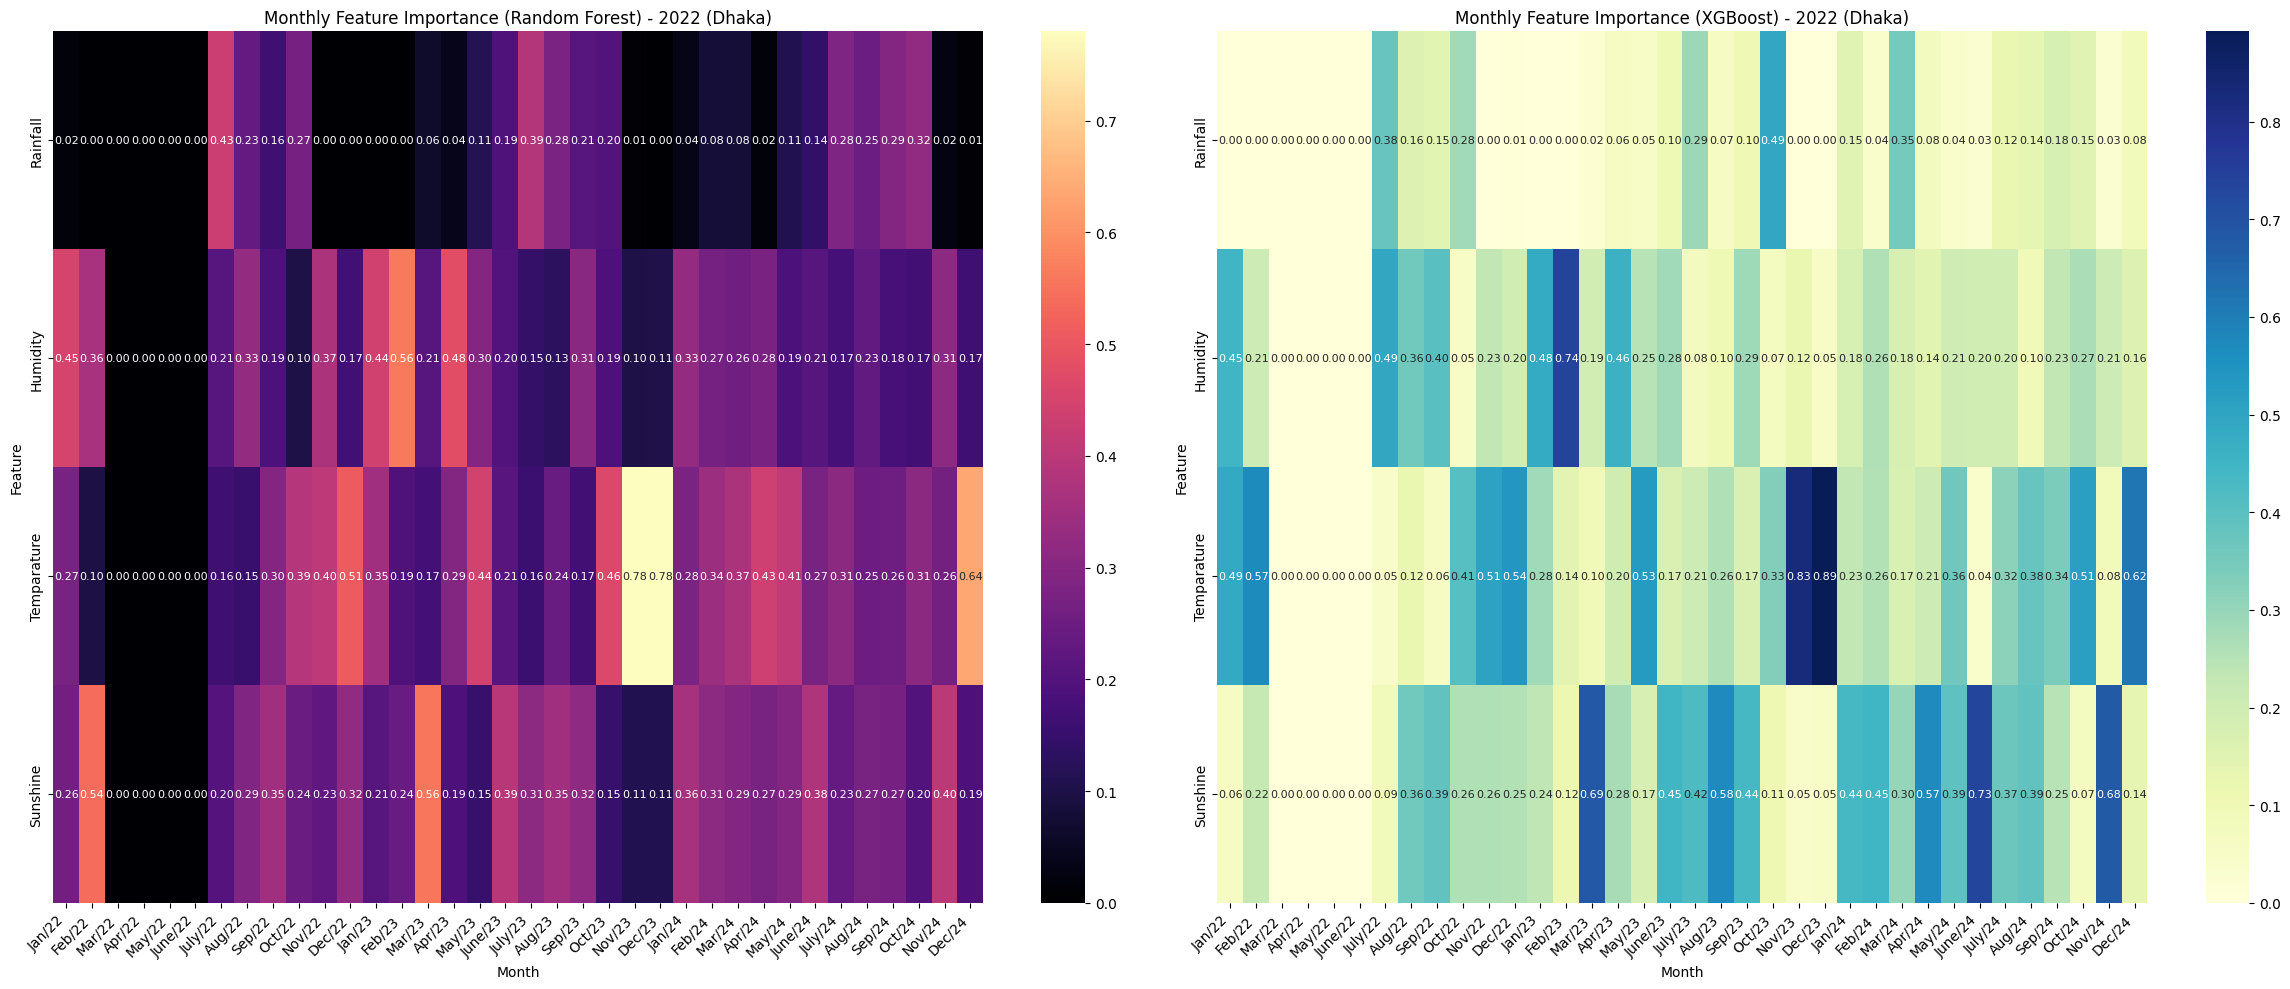

In [ ]:
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

dict1={}
dict2={}

for i, (start, end) in enumerate(ind):
    df2 = df1.iloc[start:end+1]
    #print(df2)
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
    x=df2.iloc[:, 1:]
    y=df2.iloc[:,0]
    rf_model.fit(x,y)
    rf_importances=rf_model.feature_importances_
    dict1[month[i]]=rf_importances


    xgb_model=xgb.XGBRegressor(n_estimators=200, random_state=42)
    xgb_model.fit(x,y)
    xgb_importances=xgb_model.feature_importances_
    dict2[month[i]]=xgb_importances

rf_df = pd.DataFrame(dict1, index=x.columns)
xgb_df = pd.DataFrame(dict2, index = x.columns)
print(rf_df)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 10)) # Increased figure size
sns.heatmap(rf_df, annot=True, cmap="magma", ax=axes[0], fmt=".2f", annot_kws={"size": 8}) # Increased annotation font size
#sns.heatmap(rf_importance_df.set_index('features').T, annot=True,cmap="magma",ax=axes[0])
axes[0].set_title("Monthly Feature Importance (Random Forest) - 2022 (Dhaka)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Feature")
axes[0].set_xticklabels(month, rotation=45, ha='right')


sns.heatmap(xgb_df, annot=True, cmap="YlGnBu", ax=axes[1], fmt=".2f", annot_kws={"size": 8}) # Increased annotation font size
axes[1].set_title("Monthly Feature Importance (XGBoost) - 2022 (Dhaka)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Feature")
axes[1].set_xticklabels(month, rotation=45, ha='right')
plt.tight_layout()
plt.show()